In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

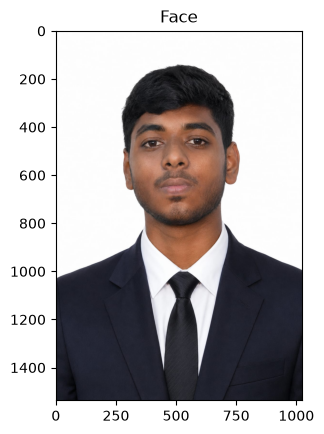

In [2]:
# Load the Face Image
faceImage = cv2.imread('myimg.jpeg')

plt.imshow(faceImage[:, :, ::-1])
plt.title("Face")
plt.show()

In [3]:
# Check the dimensions of the face image
faceImage.shape

(1537, 1023, 3)

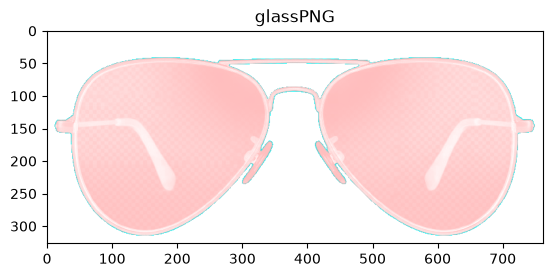

In [4]:
# Load the Sunglass image with Alpha channel
glassPNG = cv2.imread('sunglass.png', -1)

plt.imshow(glassPNG[:, :, ::-1])
plt.title("glassPNG")
plt.show()

In [33]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG, (340, 110))

print("Sunglasses Dimension =", glassPNG.shape)

Sunglasses Dimension = (110, 340, 4)


In [34]:
# Separate the Color and Alpha channels
glassBGR = glassPNG[:, :, 0:3]
glassMask1 = glassPNG[:, :, 3]

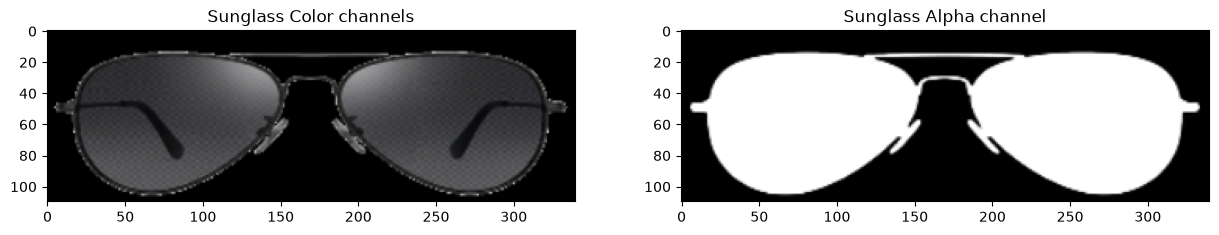

In [35]:
# Display the images for clarity
plt.figure(figsize=[15, 15])

plt.subplot(121)
plt.imshow(glassBGR[:, :, ::-1])
plt.title('Sunglass Color channels')

plt.subplot(122)
plt.imshow(glassMask1, cmap='gray')
plt.title('Sunglass Alpha channel')

plt.show()

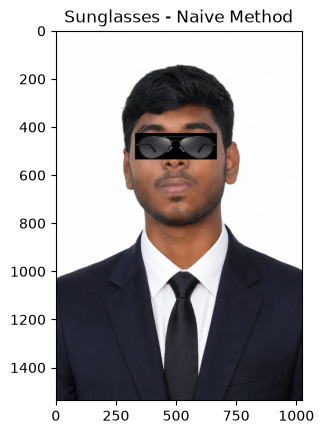

In [37]:
# Make a copy of the original image
faceWithGlassesNaive = faceImage.copy()

# Place the sunglasses over the eye region
x1 = 330
y1 = 425

x2 = x1 + glassBGR.shape[1]
y2 = y1 + glassBGR.shape[0]

faceWithGlassesNaive[y1:y2, x1:x2] = glassBGR

# Display the result
plt.imshow(faceWithGlassesNaive[:, :, ::-1])
plt.title("Sunglasses - Naive Method")
plt.show()

In [38]:
# Resize the sunglasses mask
glassMask1 = cv2.resize(glassMask1, (glassBGR.shape[1], glassBGR.shape[0]))

print("Mask Dimension =", glassMask1.shape)

Mask Dimension = (110, 340)


In [39]:
# Create a 3-channel mask
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))

# Convert mask values from 0-255 to 0-1
glassMask = np.uint8(glassMask / 255)

print("Glass Mask Dimension =", glassMask.shape)

Glass Mask Dimension = (110, 340, 3)


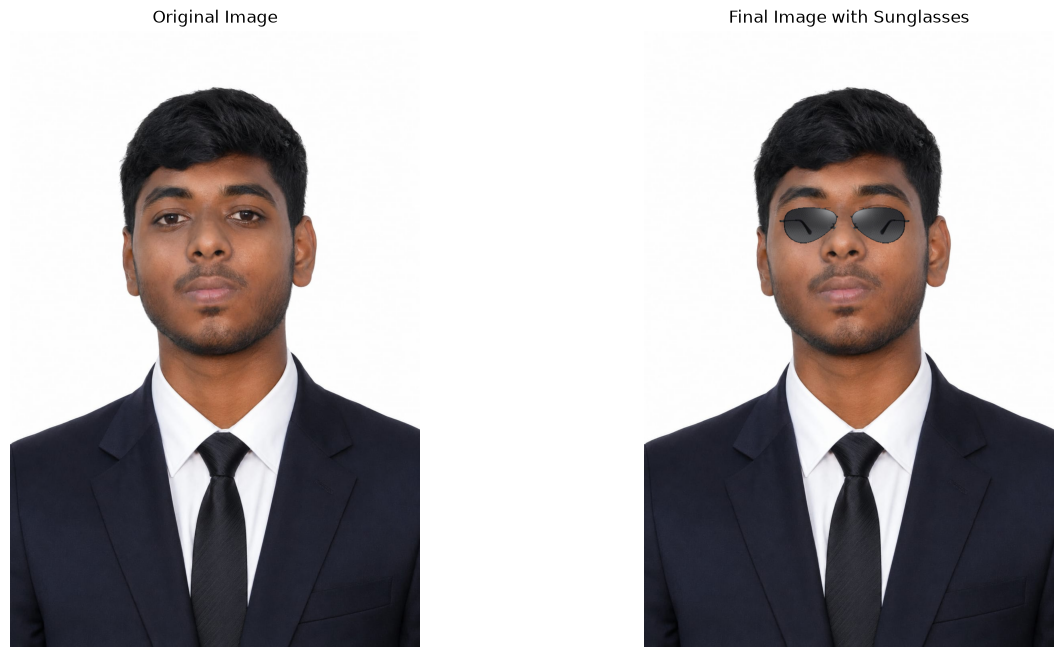

In [45]:
# Display the final result
plt.figure(figsize=(15, 8))

plt.subplot(121)
plt.imshow(faceImage[:, :, ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:, :, ::-1])
plt.title("Final Image with Sunglasses")
plt.axis("off")

plt.show()